In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import LabelEncoder

In [3]:
pdf = pd.read_csv('cognac.csv')
cognac = pd.DataFrame(pdf)

cognac.tail(10)

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
168,13.58,2.58,2.69,24.5,105,1.55,0.84,0.39,1.54,8.660000,0.74,1.80,750
169,13.40,4.60,2.86,25.0,112,1.98,0.96,0.27,1.11,8.500000,0.67,1.92,630
170,12.20,3.03,2.32,19.0,96,1.25,0.49,0.40,0.73,5.500000,0.66,1.83,510
171,12.77,2.39,2.28,19.5,86,1.39,0.51,0.48,0.64,9.899999,0.57,1.63,470
172,14.16,2.51,2.48,20.0,91,1.68,0.70,0.44,1.24,9.700000,0.62,1.71,660
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.700000,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.300000,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.200000,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.300000,0.60,1.62,840
177,14.13,4.10,2.74,24.5,96,2.05,0.76,0.56,1.35,9.200000,0.61,1.60,560


In [4]:
cognac.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [6]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
cognac_scaled = scaler.fit_transform(cognac)
cognac_scaled_df = pd.DataFrame(cognac_scaled, columns=cognac.columns)
print('Scaled feature summary (mean ≈ 0, std ≈ 1):')
cognac_scaled_df.describe().round(4)

Scaled feature summary (mean ≈ 0, std ≈ 1):


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000
mean,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000
std,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028
min,-2.4342,-1.4330,-3.6792,-2.6710,-2.0883,-2.1072,-1.6960,-1.8682,-2.0690,-1.6343,-2.0947,-1.8951,-1.4932
25%,-0.7882,-0.6587,-0.5721,-0.6891,-0.8244,-0.8855,-0.8275,-0.7401,-0.5973,-0.7951,-0.7676,-0.9522,-0.7846
50%,0.0610,-0.4231,-0.0238,0.0015,-0.1223,0.0960,0.1061,-0.1761,-0.0629,-0.1592,0.0331,0.2377,-0.2337
75%,0.8361,0.6698,0.6981,0.6021,0.5096,0.8090,0.8491,0.6095,0.6292,0.4940,0.7132,0.7886,0.7582
max,2.2598,3.1092,3.1563,3.1545,4.3714,2.5395,3.0628,2.4024,3.4851,3.4354,3.3017,1.9609,2.9715


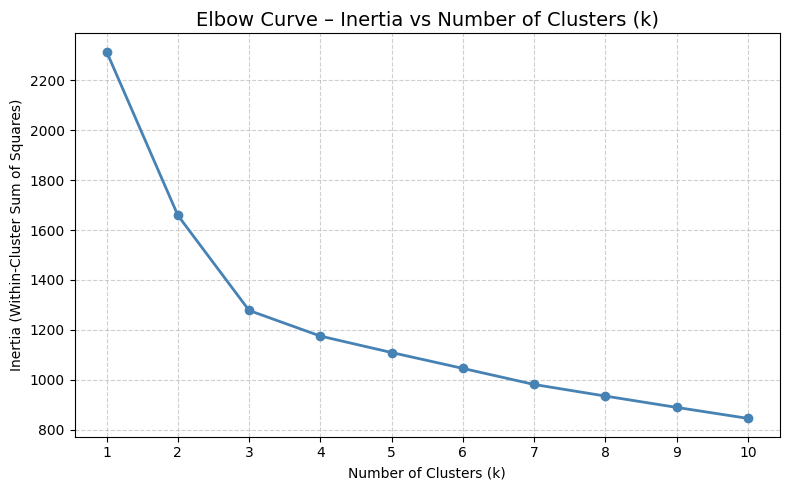

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_values = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cognac_scaled)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o', linewidth=2, color='steelblue')
plt.title('Elbow Curve – Inertia vs Number of Clusters (k)', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

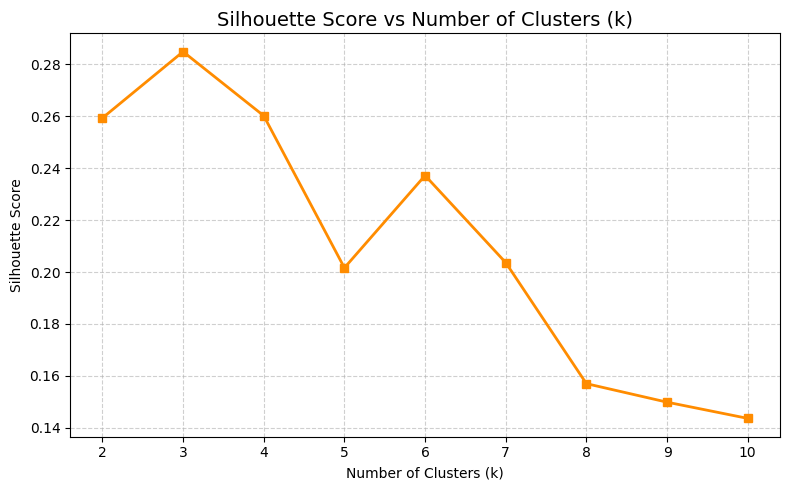

Best k by Silhouette Score: 3 (score = 0.2849)


In [8]:
silhouette_scores = []
k_range_sil = range(2, 11)

for k in k_range_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(cognac_scaled)
    score = silhouette_score(cognac_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_range_sil, silhouette_scores, marker='s', linewidth=2, color='darkorange')
plt.title('Silhouette Score vs Number of Clusters (k)', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range_sil)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

best_k_sil = k_range_sil[np.argmax(silhouette_scores)]
print(f'Best k by Silhouette Score: {best_k_sil} (score = {max(silhouette_scores):.4f})')

In [9]:
# Based on elbow and silhouette analysis, use optimal k
optimal_k = 3  # Adjust if your plots suggest a different value

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(cognac_scaled)

print('Cluster labels assigned to each data point:')
print(labels)
print(f'\nTotal labels: {len(labels)}')
print(f'Unique cluster labels: {np.unique(labels)}')

Cluster labels assigned to each data point:
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Total labels: 178
Unique cluster labels: [0 1 2]


In [10]:
# Cluster centres (in scaled space)
centres_scaled = kmeans.cluster_centers_
print('Cluster centres (scaled feature space):')
centres_df = pd.DataFrame(centres_scaled, columns=cognac.columns)
centres_df.index.name = 'Cluster'
print(centres_df.round(4))
print()

# Inverse-transform to original scale for interpretability
centres_original = scaler.inverse_transform(centres_scaled)
centres_original_df = pd.DataFrame(centres_original, columns=cognac.columns)
centres_original_df.index.name = 'Cluster'
print('Cluster centres (original feature scale):')
centres_original_df.round(2)

Cluster centres (scaled feature space):
         Alcohol  Malic_Acid     Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
Cluster                                                                        
0        -0.9261     -0.3940 -0.4945        0.1706    -0.4917        -0.0760   
1         0.1649      0.8715  0.1869        0.5244    -0.0755        -0.9793   
2         0.8352     -0.3038  0.3647       -0.6102     0.5776         0.8852   

         Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity  \
Cluster                                                                       
0            0.0208               -0.0335           0.0583          -0.9019   
1           -1.2152                0.7261          -0.7797           0.9415   
2            0.9778               -0.5621           0.5803           0.1711   

            Hue   OD280  Proline  
Cluster                           
0        0.4618  0.2708  -0.7538  
1       -1.1648 -1.2924  -0.4071  
2        0.4740  0.7792

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
Cluster,,,,,,,,,,,,,
0,12.25,1.90,2.23,20.06,92.74,2.25,2.05,0.36,1.62,2.97,1.06,2.80,510.17
1,13.13,3.31,2.42,21.24,98.67,1.68,0.82,0.45,1.15,7.23,0.69,1.70,619.06
2,13.68,2.00,2.47,17.46,107.97,2.85,3.00,0.29,1.92,5.45,1.07,3.16,1100.23
